In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, f1_score, classification_report
)
from sklearn.inspection import permutation_importance
from sklearn.model_selection import StratifiedKFold, train_test_split, cross_validate
from sklearn.impute import SimpleImputer
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE

# Dataset 4_1

## S/ SMOTE

In [11]:
# -------- 1) Carregar dados --------
from pathlib import Path

candidate_files = [Path.cwd() / "data4_1.csv", Path.cwd() / "Final" / "data4_1.csv"]
csv_path = next((path for path in candidate_files if path.exists()), None)

if csv_path is None:
    raise FileNotFoundError("Não encontrei 'data4_1.csv' na pasta atual nem em 'Final'.")

df4_1 = pd.read_csv(csv_path)
print(f"Dataset carregado de: {csv_path}")

Dataset carregado de: c:\Users\Admin\Downloads\Códigos\Códigos\Final\data4_1.csv


In [12]:
# -------- 2) Definir target, drops e features --------
target4_1 = "SECClasS_Code_Ss_1_encode"
drop_cols4_1 = ["ElementID", "source", "is_rare_class", "SECClasS_Code_Ss_1"]

features4_1 = [
    "Volume", "Area", "Length", "Height", "Thickness/Width", "Base_offset", "Top_offset",
    "Number_of_Faces", "Bounding_Box_Width", "Bounding_Box_Height", "Bounding_Box_Depth",
    "Centroid_X", "Centroid_Y", "Centroid_Z", "Orientation_Angle", "Curvature",
    "Category_Curtain Panels", "Category_Doors", "Category_Floors", "Category_Roofs",
    "Category_Stairs", "Category_Structural Columns", "Category_Structural Foundations",
    "Category_Structural Framing", "Category_Walls", "Category_Windows",
    "load_bearing_status_binary"
]

In [13]:
# -------- 3) Preparar X e y --------
df_model = df4_1.drop(columns=drop_cols4_1, errors="ignore")
X = df_model[features4_1].copy()
y = df_model[target4_1].copy()

In [14]:
# -------- 4) Train/Test Split --------
X = X.replace([np.inf, -np.inf], np.nan)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=42
)

imputer = SimpleImputer(strategy="median")
X_train = pd.DataFrame(imputer.fit_transform(X_train), columns=X.columns, index=X_train.index)
X_test  = pd.DataFrame(imputer.transform(X_test),      columns=X.columns, index=X_test.index)

# Imputar X completo para usar na Validação Cruzada (CV)
X = pd.DataFrame(imputer.transform(X), columns=X.columns, index=X.index)

In [15]:
# -------- 1) SVM sem SMOTE (usa class_weight balanced) --------
svm_no = make_pipeline(
    StandardScaler(),
    SVC(kernel="rbf", class_weight="balanced", random_state=42)
)
svm_no.fit(X_train, y_train)
pred_no = svm_no.predict(X_test)

acc_no = accuracy_score(y_test, pred_no)
bal_no = balanced_accuracy_score(y_test, pred_no)
f1m_no = f1_score(y_test, pred_no, average="macro")
f1w_no = f1_score(y_test, pred_no, average="weighted")

print("\n=== TESTE — SVM SEM SMOTE ===")
print(f"Accuracy:         {acc_no:.4f}")
print(f"Balanced Accuracy:{bal_no:.4f}")
print(f"F1-macro:         {f1m_no:.4f}")
print(f"F1-weighted:      {f1w_no:.4f}")
print("\nClassification report:")
print(classification_report(y_test, pred_no, digits=4))


=== TESTE — SVM SEM SMOTE ===
Accuracy:         0.8643
Balanced Accuracy:0.9418
F1-macro:         0.6660
F1-weighted:      0.9102

Classification report:
              precision    recall  f1-score   support

           0     0.9948    0.9896    0.9922       771
           1     0.9965    0.8233    0.9017      2802
           2     0.8839    0.9612    0.9209       103
           3     0.7241    1.0000    0.8400        21
           4     0.0986    0.9767    0.1791        43
           5     0.0891    0.9000    0.1622        10

    accuracy                         0.8643      3750
   macro avg     0.6312    0.9418    0.6660      3750
weighted avg     0.9788    0.8643    0.9102      3750



In [16]:
# -------- 2) SVM com SMOTE --------
svm_sm = ImbPipeline(steps=[
    ("smote", SMOTE(random_state=42)),
    ("scaler", StandardScaler()),
    ("svm", SVC(kernel="rbf", random_state=42))
])
svm_sm.fit(X_train, y_train)
pred_sm = svm_sm.predict(X_test)

acc_sm = accuracy_score(y_test, pred_sm)
bal_sm = balanced_accuracy_score(y_test, pred_sm)
f1m_sm = f1_score(y_test, pred_sm, average="macro")
f1w_sm = f1_score(y_test, pred_sm, average="weighted")

print("\n=== TESTE — SVM COM SMOTE ===")
print(f"Accuracy:         {acc_sm:.4f}")
print(f"Balanced Accuracy:{bal_sm:.4f}")
print(f"F1-macro:         {f1m_sm:.4f}")
print(f"F1-weighted:      {f1w_sm:.4f}")
print("\nClassification report:")
print(classification_report(y_test, pred_sm, digits=4))


=== TESTE — SVM COM SMOTE ===
Accuracy:         0.9403
Balanced Accuracy:0.9829
F1-macro:         0.7433
F1-weighted:      0.9564

Classification report:
              precision    recall  f1-score   support

           0     0.9871    0.9948    0.9910       771
           1     0.9988    0.9222    0.9590      2802
           2     0.8783    0.9806    0.9266       103
           3     0.9130    1.0000    0.9545        21
           4     0.2606    1.0000    0.4135        43
           5     0.1205    1.0000    0.2151        10

    accuracy                         0.9403      3750
   macro avg     0.6931    0.9829    0.7433      3750
weighted avg     0.9818    0.9403    0.9564      3750



In [17]:
import sys
from pathlib import Path

candidate_module_dirs = [Path.cwd(), Path.cwd() / "Final"]
for module_dir in candidate_module_dirs:
    if (module_dir / "inference_artifacts.py").exists():
        module_dir_str = str(module_dir)
        if module_dir_str not in sys.path:
            sys.path.insert(0, module_dir_str)

from inference_artifacts import ensure_artifact_dirs, save_model_bundle

dirs = ensure_artifact_dirs()
svm_no_path = save_model_bundle(
    name="svm4_1_sem_smote",
    estimator=svm_no,
    imputer=imputer,
    features=X.columns,
    target_column=target4_1,
    class_labels=np.sort(pd.unique(y)),
    metrics={"accuracy": acc_no, "balanced_accuracy": bal_no, "f1_macro": f1m_no, "f1_weighted": f1w_no},
    metadata={"algorithm": "SVC", "dataset": "data4_1.csv", "variant": "sem_smote", "source_notebook": "svm4_1.ipynb"},
)
svm_sm_path = save_model_bundle(
    name="svm4_1_com_smote",
    estimator=svm_sm,
    imputer=imputer,
    features=X.columns,
    target_column=target4_1,
    class_labels=np.sort(pd.unique(y)),
    metrics={"accuracy": acc_sm, "balanced_accuracy": bal_sm, "f1_macro": f1m_sm, "f1_weighted": f1w_sm},
    metadata={"algorithm": "SVC", "dataset": "data4_1.csv", "variant": "com_smote", "source_notebook": "svm4_1.ipynb"},
)

print(f"Modelo guardado em: {svm_no_path}")
print(f"Modelo guardado em: {svm_sm_path}")

Modelo guardado em: c:\Users\Admin\Downloads\Códigos\Códigos\Final\artifacts\models\svm4_1_sem_smote.pkl
Modelo guardado em: c:\Users\Admin\Downloads\Códigos\Códigos\Final\artifacts\models\svm4_1_com_smote.pkl


Sem SMOTE o SVM “força” muito recall nas classes pequenas (ex.: 4 e 5), mas com precisão baixíssima → muitos falsos positivos.

Com SMOTE sobe bastante o accuracy e o f1_weighted, e melhora a macro, mas ainda fica bem abaixo do RF.

In [18]:
# -------- 3) Validação Cruzada (para robustez) --------
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scorings = {
    "acc": "accuracy",
    "bal_acc": "balanced_accuracy",
    "f1_macro": "f1_macro",
    "f1_weighted": "f1_weighted"
}

# CV sem SMOTE
cv_no = cross_validate(svm_no, X, y, cv=cv, scoring=scorings, n_jobs=-1)

# CV com SMOTE
cv_sm = cross_validate(svm_sm, X, y, cv=cv, scoring=scorings, n_jobs=-1)

def resumo_cv(nome, res):
    print(f"\n=== CV (5-fold) — {nome} ===")
    for k in scorings.keys():
        vals = res[f"test_{k}"]
        print(f"{k:12s}: {vals.mean():.4f} ± {vals.std():.4f} "
              f"(min={vals.min():.4f}, max={vals.max():.4f})")

resumo_cv("SVM SEM SMOTE", cv_no)
resumo_cv("SVM COM SMOTE", cv_sm)


=== CV (5-fold) — SVM SEM SMOTE ===
acc         : 0.8678 ± 0.0047 (min=0.8592, max=0.8728)
bal_acc     : 0.9497 ± 0.0183 (min=0.9159, max=0.9653)
f1_macro    : 0.6710 ± 0.0080 (min=0.6602, max=0.6798)
f1_weighted : 0.9123 ± 0.0029 (min=0.9068, max=0.9150)

=== CV (5-fold) — SVM COM SMOTE ===
acc         : 0.9494 ± 0.0056 (min=0.9427, max=0.9568)
bal_acc     : 0.9671 ± 0.0145 (min=0.9432, max=0.9859)
f1_macro    : 0.7521 ± 0.0163 (min=0.7253, max=0.7712)
f1_weighted : 0.9621 ± 0.0033 (min=0.9577, max=0.9661)


In [19]:
# --- 3) Função utilitária para Permutation Importance ---
def compute_perm_importance(model, X_test, y_test, feature_names, scoring="balanced_accuracy",
                            n_repeats=10, random_state=42, n_jobs=-1, top_n=15, title_suffix=""):
    """
    Calcula permutation importance no conjunto de TESTE.
    Retorna DataFrame ordenado e mostra gráfico das top N features.
    """
    print(f"\nCalculando Permutation Importance ({title_suffix}) ...")
    result = permutation_importance(
        model, X_test, y_test,
        scoring=scoring,
        n_repeats=n_repeats,
        random_state=random_state,
        n_jobs=n_jobs
    )
    imp_df = pd.DataFrame({
        "Feature": feature_names,
        "Importance_mean": result.importances_mean,
        "Importance_std": result.importances_std
    }).sort_values("Importance_mean", ascending=False)

    print(imp_df.head(top_n))

    # Gráfico Top N
    top = imp_df.head(top_n).iloc[::-1]  # inverter para barra horizontal bonita
    plt.figure(figsize=(9, max(5, 0.35*len(top))))
    plt.barh(top["Feature"], top["Importance_mean"], xerr=top["Importance_std"])
    plt.xlabel(f"Permutation importance (média Δ {scoring})")
    plt.title(f"Permutation Importance — SVM RBF {title_suffix}")
    plt.tight_layout()
    plt.show()

    return imp_df



Calculando Permutation Importance ((SEM SMOTE)) ...
                        Feature  Importance_mean  Importance_std
13                   Centroid_Z         0.207319        0.026495
18              Category_Floors         0.141023        0.009295
20              Category_Stairs         0.122470        0.004800
23  Category_Structural Framing         0.119658        0.008743
3                        Height         0.106351        0.016108
21  Category_Structural Columns         0.082369        0.013423
10           Bounding_Box_Depth         0.042409        0.017601
11                   Centroid_X         0.040941        0.018840
6                    Top_offset         0.040712        0.005699
4               Thickness/Width         0.035663        0.016265
14            Orientation_Angle         0.023886        0.014073
17               Category_Doors         0.016959        0.014093
25             Category_Windows         0.014987        0.011311
7               Number_of_Faces      

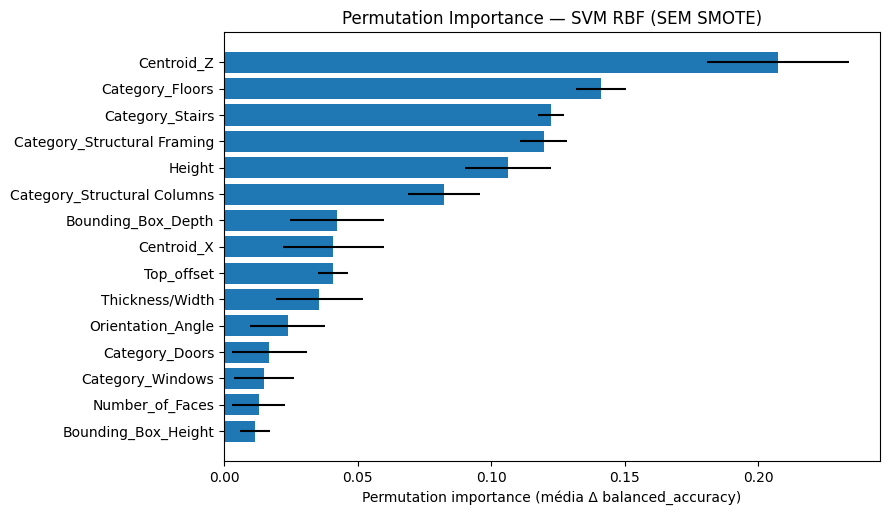


Calculando Permutation Importance ((COM SMOTE)) ...


In [ ]:
# --- 4) Rodar Permutation Importance (balanced_accuracy) ---
imp_no   = compute_perm_importance(
    svm_no, X_test, y_test, feature_names=X.columns,
    scoring="balanced_accuracy", n_repeats=10, title_suffix="(SEM SMOTE)"
)

imp_sm   = compute_perm_importance(
    svm_sm, X_test, y_test, feature_names=X.columns,
    scoring="balanced_accuracy", n_repeats=10, title_suffix="(COM SMOTE)"
)

In [ ]:
# ============================================================
# EXPORTAÇÃO DO MODELO PARA INFERÊNCIA
# ============================================================
# Guarda o encoder e os dois modelos treinados.
# Na inferência, os dados já chegam preparados pelo pipeline
# de data preparation, por isso não é necessário guardar o imputer.
#
# Ficheiros gerados (pasta Final/models/):
#   encoder_4_1.pkl   — LabelEncoder: converte número de volta para código SEC
#   svm_4_1.pkl       — SVM (RBF) treinado SEM SMOTE
#   svm_sm_4_1.pkl    — SVM (RBF) treinado COM SMOTE
# ============================================================

import joblib
from pathlib import Path
from sklearn.preprocessing import LabelEncoder

# ---------- Pasta de destino ----------
models_dir = csv_path.parent / "models"
models_dir.mkdir(exist_ok=True)

# ---------- Encoder do target ----------
encoder = LabelEncoder()
encoder.fit(df4_1["SECClasS_Code_Ss_1"].astype(str))
joblib.dump(encoder, models_dir / "encoder_4_1.pkl")
print(f"[OK] Encoder guardado → {models_dir / 'encoder_4_1.pkl'}")

# ---------- Modelos ----------
joblib.dump(svm_no, models_dir / "svm_4_1.pkl")
print(f"[OK] SVM (RBF) (SEM SMOTE) guardado → {models_dir / 'svm_4_1.pkl'}")

joblib.dump(svm_sm, models_dir / "svm_sm_4_1.pkl")
print(f"[OK] SVM (RBF) (COM SMOTE) guardado → {models_dir / 'svm_sm_4_1.pkl'}")

print("\n=== Exportação concluída! ===")
print("Para fazer inferência em dados novos:")
print("  import joblib")
print("  encoder = joblib.load('Final/models/encoder_4_1.pkl')")
print("  model   = joblib.load('Final/models/svm_4_1.pkl')  # ou svm_sm_4_1.pkl")
print("  pred    = encoder.inverse_transform(model.predict(X_new))")